In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s4e12/sample_submission.csv
/kaggle/input/playground-series-s4e12/train.csv
/kaggle/input/playground-series-s4e12/test.csv


In [2]:
df = pd.read_csv("/kaggle/input/playground-series-s4e12/train.csv")
test = pd.read_csv("/kaggle/input/playground-series-s4e12/test.csv")
submission = pd.read_csv("/kaggle/input/playground-series-s4e12/sample_submission.csv")
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pan

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,...,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type,Premium Amount
0,0,19.0,Female,10049.0,Married,1.0,Bachelor's,Self-Employed,22.598761,Urban,...,2.0,17.0,372.0,5.0,2023-12-23 15:21:39.134960,Poor,No,Weekly,House,2869.0
1,1,39.0,Female,31678.0,Divorced,3.0,Master's,NaN,15.569731,Rural,...,1.0,12.0,694.0,2.0,2023-06-12 15:21:39.111551,Average,Yes,Monthly,House,1483.0
2,2,23.0,Male,25602.0,Divorced,3.0,High School,Self-Employed,47.177549,Suburban,...,1.0,14.0,NaN,3.0,2023-09-30 15:21:39.221386,Good,Yes,Weekly,House,567.0
3,3,21.0,Male,141855.0,Married,2.0,Bachelor's,NaN,10.938144,Rural,...,1.0,0.0,367.0,1.0,2024-06-12 15:21:39.226954,Poor,Yes,Daily,Apartment,765.0
4,4,21.0,Male,39651.0,Single,1.0,Bachelor's,Self-Employed,20.376094,Rural,...,0.0,8.0,598.0,4.0,2021-12-01 15:21:39.252145,Poor,Yes,Weekly,House,2022.0


In [3]:
df.shape

(1200000, 21)

In [4]:
df.columns

Index(['id', 'Age', 'Gender', 'Annual Income', 'Marital Status',
       'Number of Dependents', 'Education Level', 'Occupation', 'Health Score',
       'Location', 'Policy Type', 'Previous Claims', 'Vehicle Age',
       'Credit Score', 'Insurance Duration', 'Policy Start Date',
       'Customer Feedback', 'Smoking Status', 'Exercise Frequency',
       'Property Type', 'Premium Amount'],
      dtype='object')

## Разделение данных на train и test

In [5]:
from sklearn.model_selection import train_test_split

y = df["Premium Amount"]
X = df.drop(columns=["Premium Amount"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Значения целевой переменной и их распределение

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Premium Amount', ylabel='Count'>

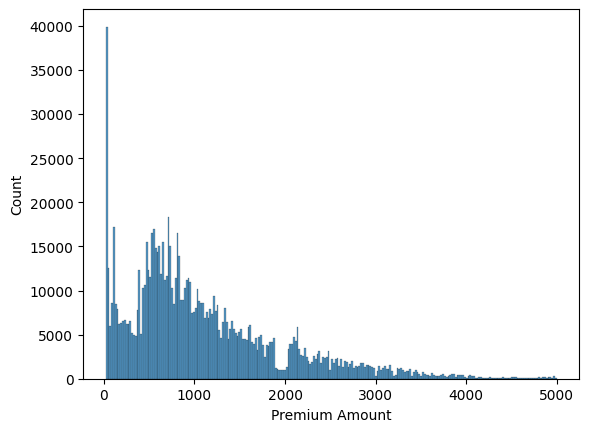

In [6]:
sns.histplot(y_train)

1) примерно 40000 человек не получили премию
2) премию от 1000 до 2000 получили 


In [7]:
# Создаем бины (промежутки)
bins = [0, 1000, 2000, 3000, 4000, 5000, np.inf]
labels = ['0-1000', '1000-2000', '2000-3000', '3000-4000', '4000-5000', '5000+']

# Добавляем столбец с бинами
df['premium_range'] = pd.cut(df['Premium Amount'], bins=bins, labels=labels, right=False)

# Группируем по бинам и считаем статистики
result = df.groupby('premium_range').agg(
    count=('Premium Amount', 'count'),
    avg_amount=('Premium Amount', 'mean')
).reset_index()

result['percentage'] = (result['count'] / len(df) * 100).round(2)
print(result)

  premium_range   count   avg_amount  percentage
0        0-1000  679099   515.793777       56.59
1     1000-2000  331855  1388.523596       27.65
2     2000-3000  139688  2409.047098       11.64
3     3000-4000   41420  3384.276437        3.45
4     4000-5000    7938  4446.781179        0.66
5         5000+       0          NaN        0.00


/tmp/ipykernel_13/1240495629.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby('premium_range').agg(
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Из этого можно понять, что малые премии составляют 56 процентов, с увеличением кол-ва премии, кол-во получивших её очень сильно уменьшается
Большинство предсказания аж 84% будет в премии до 2000 

2000+ 16%


Сделаю разделение на 3 класса
1) класс от 0 до 1000 
2) класс от 1000 до 2000
3) класс от 2000 до 5000


In [8]:
# df["range_0_1000"] = ((df["Premium Amount"] > 0) && (df["Premium Amount"] <= 1000)).astype(int)
# df["range_1000_2000"] = ((df["Premium Amount"] > 1000) && (df["Premium Amount"] <= 2000)).astype(int)
# df["range_2000_5000"] = ((df["Premium Amount"] > 2000) && (df["Premium Amount"] <= 5000)).atype(int)


## Коэффициент корреляции Пирсона между признаками и целевой переменной

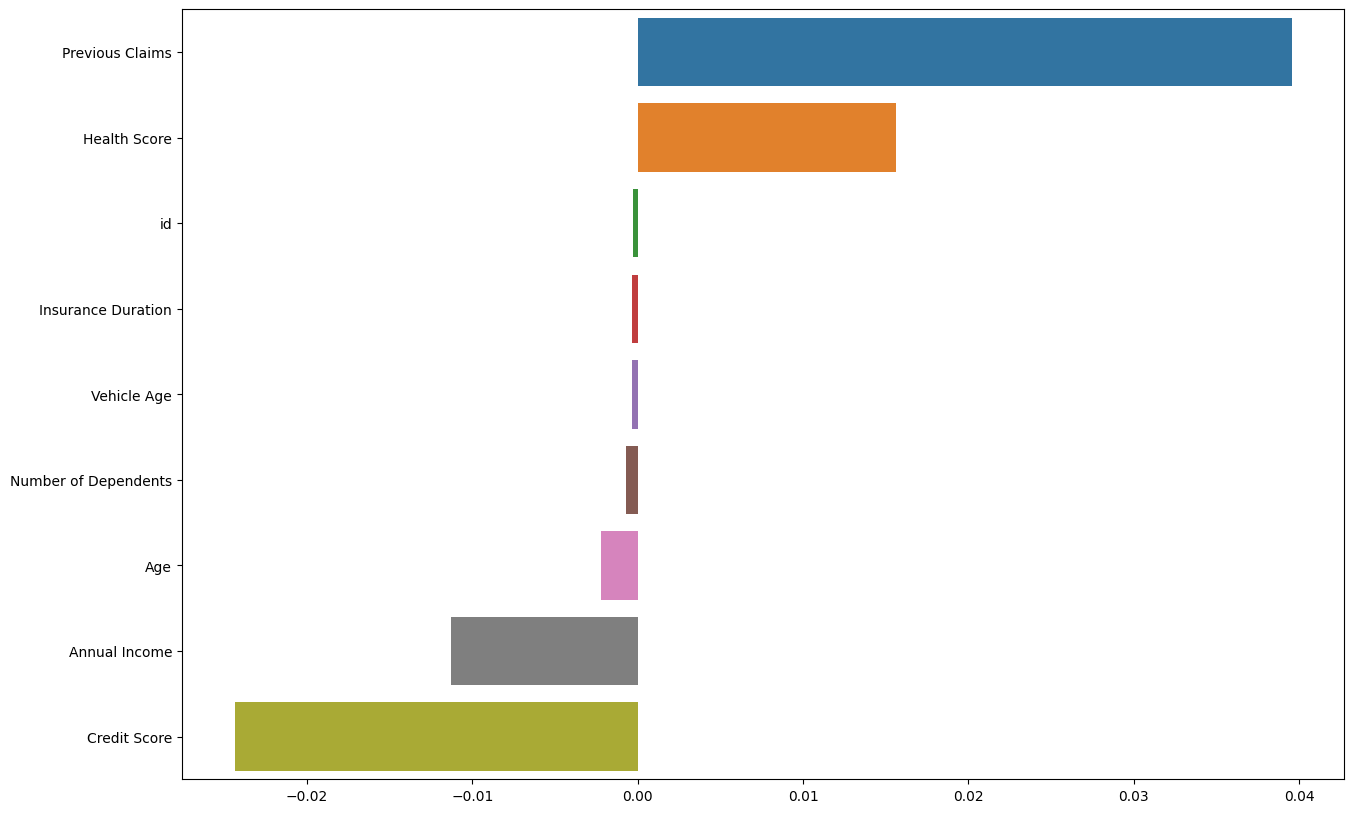

In [9]:
numeric_data = X_train.select_dtypes([np.number])
numeric_data_mean = numeric_data.mean()
numeric_features = numeric_data.columns

X_train = X_train.fillna(numeric_data_mean)
X_test = X_test.fillna(numeric_data_mean)
test = test.fillna(numeric_data_mean)

correlations = X_train[numeric_features].corrwith(y_train).sort_values(ascending=False)

plot = sns.barplot(y=correlations.index, x=correlations)
plot.figure.set_size_inches(15, 10)

## Анализ категориальных признаков

In [10]:
categorical = X_train.select_dtypes(include=['object']).columns
X_train[categorical].nunique()

Gender                     2
Marital Status             3
Education Level            4
Occupation                 3
Location                   3
Policy Type                3
Policy Start Date     163166
Customer Feedback          3
Smoking Status             2
Exercise Frequency         4
Property Type              3
dtype: int64

## Обработка Policy Start Date     

In [11]:
X_train["Policy Start Date"] = pd.to_datetime(X_train["Policy Start Date"])
X_train["year_Policy Start Date"] = X_train["Policy Start Date"].dt.year
X_train["month_Policy Start Date"] = X_train["Policy Start Date"].dt.month
X_train["day_Policy Start Date"] = X_train["Policy Start Date"].dt.day
X_train["hour_Policy Start Date"] = X_train["Policy Start Date"].dt.hour
X_train["minute_Policy Start Date"] = X_train["Policy Start Date"].dt.minute

In [12]:
X_train = X_train.drop(columns = ["Policy Start Date"])

In [13]:
X_test["Policy Start Date"] = pd.to_datetime(X_test["Policy Start Date"])
X_test["year_Policy Start Date"] = X_test["Policy Start Date"].dt.year
X_test["month_Policy Start Date"] = X_test["Policy Start Date"].dt.month
X_test["day_Policy Start Date"] = X_test["Policy Start Date"].dt.day
X_test["hour_Policy Start Date"] = X_test["Policy Start Date"].dt.hour
X_test["minute_Policy Start Date"] = X_test["Policy Start Date"].dt.minute

In [14]:
X_test = X_test.drop(columns = ["Policy Start Date"])

In [15]:
test["Policy Start Date"] = pd.to_datetime(test["Policy Start Date"])
test["year_Policy Start Date"] = test["Policy Start Date"].dt.year
test["month_Policy Start Date"] = test["Policy Start Date"].dt.month
test["day_Policy Start Date"] = test["Policy Start Date"].dt.day
test["hour_Policy Start Date"] = test["Policy Start Date"].dt.hour
test["minute_Policy Start Date"] = test["Policy Start Date"].dt.minute

In [16]:
test = test.drop(columns = ["Policy Start Date"])

## One hot кодирование

In [17]:
categorical = X_train.select_dtypes(include=['object']).columns
X_train_encoded = pd.get_dummies(X_train, columns=categorical, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, columns=categorical, drop_first=False)

# Если в тесте появляются новые категории, которых нет в train:
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [18]:
test_encoded = pd.get_dummies(test, columns=categorical, drop_first=False)
test_encoded = test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

In [19]:
numeric_features = X_train.select_dtypes(include=['number']).columns
X_train_final = pd.concat([X_train[numeric_features], X_train_encoded], axis=1)
X_test_final = pd.concat([X_test[numeric_features], X_test_encoded], axis=1)

In [20]:
numeric_features = test.select_dtypes(include=['number']).columns
test_final = pd.concat([test[numeric_features], test_encoded], axis=1)


In [21]:
test[categorical] = test[categorical].fillna('Unknown')

## Обучение модели

In [22]:
from sklearn.metrics import mean_squared_log_error, make_scorer
import numpy as np

# RMSLE scorer
def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)  # меньше лучше

In [23]:
from sklearn.ensemble import RandomForestRegressor

best_params = {
    'n_estimators': 100,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'max_features': 'sqrt',
    'max_depth': 15
}

best_model = RandomForestRegressor(**best_params, random_state=42)
best_model.fit(X_train_final, y_train)

RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=2,
                      min_samples_split=5, random_state=42)

In [24]:
y_pred_test = best_model.predict(test_final)

In [25]:
test_ids = test['id']  # это 1D Series

In [26]:
submission = pd.DataFrame({
    'id': test_ids,               
    'Premium Amount': y_pred_test   
})
submission.to_csv('submission.csv', index=False)